In [1]:
import scanpy as sc
import anndata as ad

from CODA.utils import *
from CODA.RGBgenerator import *
from CODA.Common_domain import *
from CODA.Preprocessing import *
from CODA.Alignment import *

D:\anaconda\envs\CODA\lib\site-packages\CODA\Common_domain.py:220: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @torch.cuda.amp.custom_fwd(cast_inputs=torch.float32)


# Loading data

In [2]:
adata_ZT4_F_Saline = sc.read_h5ad('GSM6704280_ZT4_F_Saline_filtered_feature_bc_matrix_processed.h5ad')
adata_ZT4_F_RHY = sc.read_h5ad('GSM6704281_ZT4_F_RHY_filtered_feature_bc_matrix_processed.h5ad')

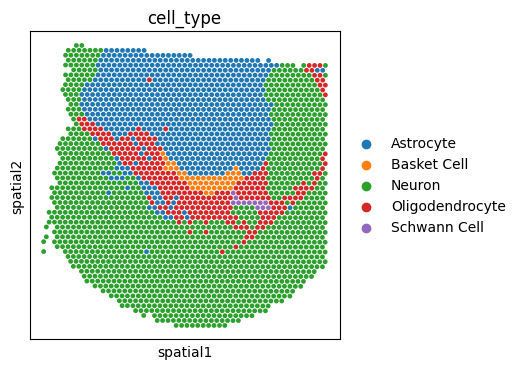

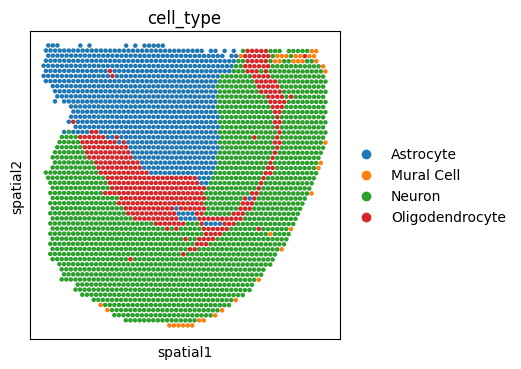

In [3]:
plt.rcParams['figure.figsize']=[4,4]
sc.pl.embedding(adata_ZT4_F_Saline, basis='spatial', color='cell_type')
sc.pl.embedding(adata_ZT4_F_RHY, basis='spatial', color='cell_type')

# Select the common HVGs

In [4]:
sc.pp.highly_variable_genes(adata_ZT4_F_Saline, flavor="seurat", n_top_genes=3000)
sc.pp.highly_variable_genes(adata_ZT4_F_RHY, flavor="seurat", n_top_genes=3000)

hvg_saline = set(adata_ZT4_F_Saline.var[adata_ZT4_F_Saline.var['highly_variable']].index)
hvg_rhy = set(adata_ZT4_F_RHY.var[adata_ZT4_F_RHY.var['highly_variable']].index)

hvg_intersection = hvg_saline.intersection(hvg_rhy)
print(f"Number of shared HVGs: {len(hvg_intersection)}")

adata_ZT4_F_Saline_filtered = adata_ZT4_F_Saline[:, list(hvg_intersection)].copy()
adata_ZT4_F_RHY_filtered = adata_ZT4_F_RHY[:, list(hvg_intersection)].copy()

adata_combined = adata_ZT4_F_Saline_filtered.concatenate(
    adata_ZT4_F_RHY_filtered, 
    batch_key='batch', 
    batch_categories=['saline', 'rhy']
)

Number of shared HVGs: 1288


C:\Users\Administrator\AppData\Local\Temp\ipykernel_15656\2800030630.py:13: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  adata_combined = adata_ZT4_F_Saline_filtered.concatenate(


# Integrating

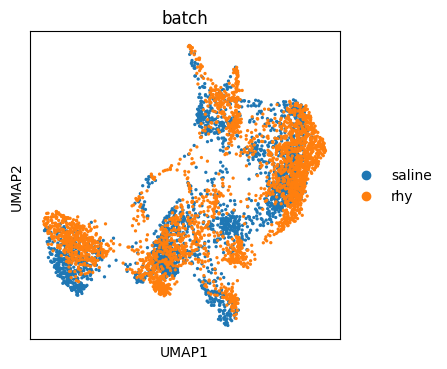

In [5]:
sc.pp.normalize_total(adata_combined, target_sum=1e4)
sc.pp.log1p(adata_combined)

sc.tl.pca(adata_combined, n_comps=30)

sc.pp.combat(adata_combined, key='batch')

sc.pp.neighbors(adata_combined)
sc.tl.umap(adata_combined, n_components=3)
sc.pl.umap(adata_combined, color=['batch'])

# Generating the images of ST slices

In [ ]:
umap_3d = adata_combined.obsm['X_umap']  

umap_min = umap_3d.min(axis=0)
umap_max = umap_3d.max(axis=0)
umap_normalized = (umap_3d - umap_min) / (umap_max - umap_min)
umap_rgb = np.round(umap_normalized * 255).astype(int)

batch_info = adata_combined.obs['batch'].values
umap_rgb_saline = umap_rgb[batch_info == 'saline']
umap_rgb_rhy = umap_rgb[batch_info == 'rhy']

In [7]:
adata_ZT4_F_Saline_integrated = adata_combined[batch_info == 'saline']
adata_ZT4_F_RHY_integrated = adata_combined[batch_info == 'rhy']

In [8]:
embedding_ST1 = umap_rgb_saline/255
embedding_ST2 = umap_rgb_rhy/255

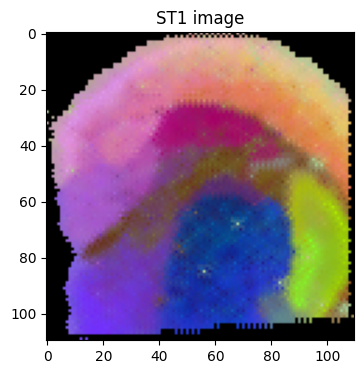

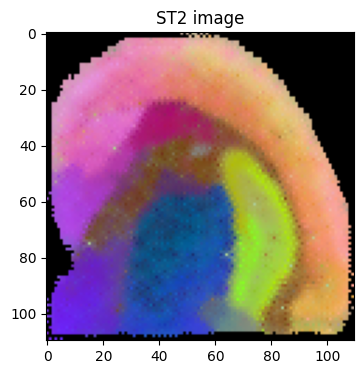

In [9]:
coords_ST1 = adata_ZT4_F_Saline_integrated.obsm['spatial']
ST1_generator = RGBImageGenerator(img_size=(110,110))
img_ST1, mapping_ST1 = ST1_generator.create_rgb_image_with_mapping(coords_ST1, embedding_ST1*255)
img_ST1_interpolated = ST1_generator.interpolate_zero_pixels(img_ST1,2)
ST1_generator.show_image(img_ST1_interpolated,title='ST1 image')

coords_ST2 = adata_ZT4_F_RHY_integrated.obsm['spatial']
ST2_generator = RGBImageGenerator(img_size=(110,110))
img_ST2, mapping_ST2 = ST2_generator.create_rgb_image_with_mapping(coords_ST2, embedding_ST2*255)
img_ST2_interpolated = ST2_generator.interpolate_zero_pixels(img_ST2,2)
ST2_generator.show_image(img_ST2_interpolated,title='ST2 image')

# Identifying the common domain

In [10]:
image0 = torch.from_numpy(img_ST1_interpolated/255).permute(2, 0, 1)
image0 = image0.to(torch.float32)
image1 = torch.from_numpy(img_ST2_interpolated/255).permute(2, 0, 1)
image1 = image1.to(torch.float32)

In [11]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu") 

extractor = CustomSPNet(max_num_keypoints=2048).eval().to(device) 
matcher = LightGlue(features="superpoint").eval().to(device)

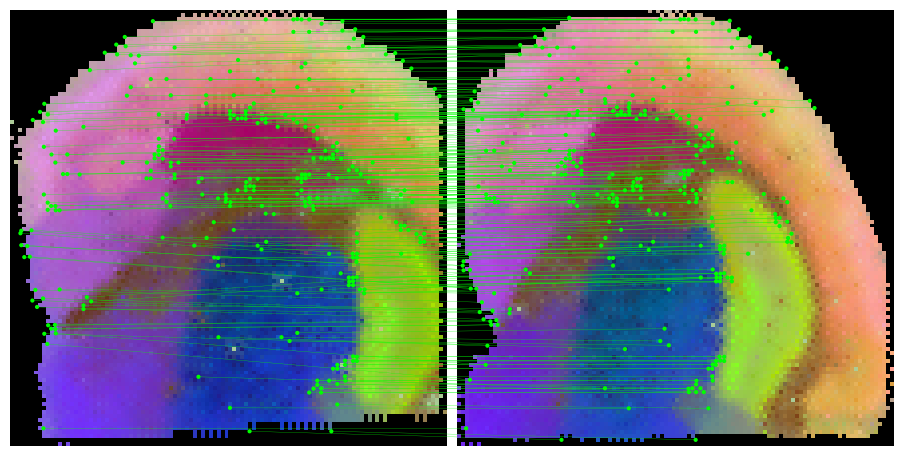

In [12]:
m_kpts0, m_kpts1,matches01 = extract_and_match_keypoints(
    image0, image1, extractor, matcher, device="cuda"
)

array([<Axes: >, <Axes: >], dtype=object)

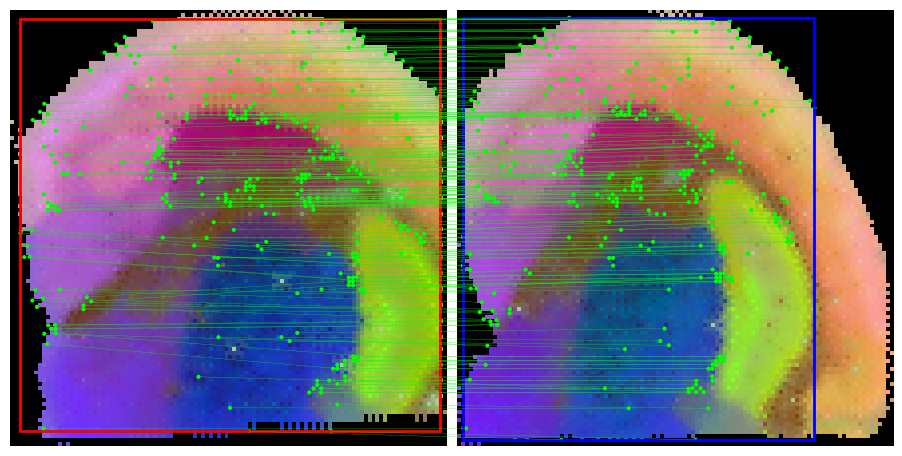

In [13]:
plot_match_regions(image0, image1, m_kpts0, m_kpts1, matches01, matches01["prune0"], matches01["prune1"], mode="bbox")

array([<Axes: >, <Axes: >], dtype=object)

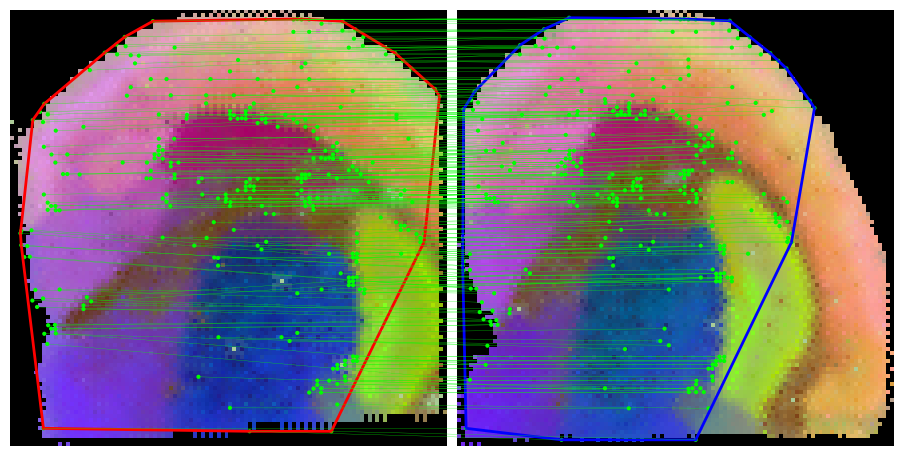

In [14]:
plot_match_regions(image0, image1, m_kpts0, m_kpts1, matches01, matches01["prune0"], matches01["prune1"], mode="convex")

# Extract the common domain

In [15]:
kpts0_np = m_kpts0.cpu().numpy()
kpts1_np = m_kpts1.cpu().numpy()

In [16]:
from shapely.geometry import Polygon

hull0 = kpts0_np[ConvexHull(kpts0_np).vertices]
hull1 = kpts1_np[ConvexHull(kpts1_np).vertices]

poly0 = Polygon(hull0)
poly1 = Polygon(hull1)

cells_in_saline = extract_cells_from_polygon(poly0, mapping_ST1)
cells_in_rhy = extract_cells_from_polygon(poly1, mapping_ST2)

In [17]:
extracted_cells_rep1 = extract_cells_by_indices(adata_ZT4_F_Saline, cells_in_saline)
extracted_cells_rep2 = extract_cells_by_indices(adata_ZT4_F_RHY, cells_in_rhy)

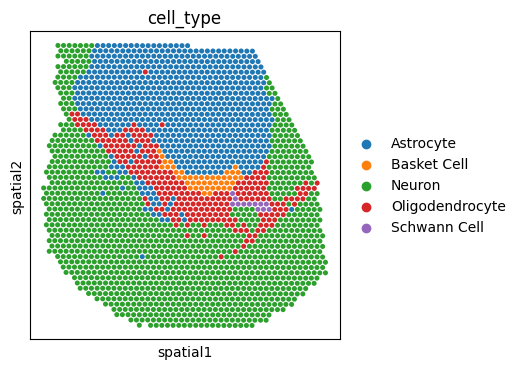

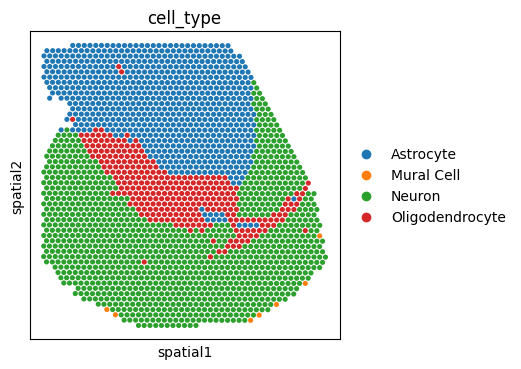

In [18]:
sc.pl.embedding(extracted_cells_rep1, color='cell_type', basis='spatial')
sc.pl.embedding(extracted_cells_rep2, color='cell_type', basis='spatial')